In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated,Optional,List
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage,AIMessage,SystemMessage,ToolMessage
from dotenv import load_dotenv
from langchain_community.tools import TavilySearchResults
from langgraph.checkpoint.memory import InMemorySaver
from uuid import uuid4
import psycopg2
import os
load_dotenv()

/var/folders/4r/9cc0tjg51p13g6sf2rd7c2lh0000gn/T/ipykernel_59136/3189452860.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import TavilySearchResults


True

In [2]:
llm=ChatGroq(model="llama-3.3-70b-versatile")
search_tool=TavilySearchResults(max_results=3, tavily_api_key=os.getenv("TAVILY_KEY"))
tools=[search_tool]
llm_with_tools=llm.bind_tools(tools=tools)

/var/folders/4r/9cc0tjg51p13g6sf2rd7c2lh0000gn/T/ipykernel_59136/2800103668.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool=TavilySearchResults(max_results=3, tavily_api_key=os.getenv("TAVILY_KEY"))


In [3]:
class state(TypedDict):
    messages: Annotated[list, add_messages]
    route: Optional[str]
    sql_query: Optional[str]
    sql_results: Optional[str]

In [4]:
async def llm_node(state:state)->state:
    res=await llm_with_tools.ainvoke(state["messages"])
    return {"messages":[res]}

async def router(state:state)->str:
    last_msg=state['messages'][-1]
    if last_msg.tool_calls:
        return "tools"
    return "end"





async def routerNode(state:state):
    ROUTER_PROMPT = """You are a routing classifier for Homemakers, a real estate platform in India.
Your only job is to read the user's message and decide which of three categories it belongs to.

Respond with EXACTLY ONE WORD: sql, search, or chat. Nothing else. No punctuation, no explanation.

Use "sql" when the user is asking to find, search, filter, or browse properties based on 
specific criteria that would be stored in a database, such as:
- Location (city, state, district, locality)
- Price or rent budget (under X, between X and Y)
- Property type (apartment, villa, independent house)
- Number of bedrooms/bathrooms, area in sqft
- Availability (for rent, for sale)
- Amenities (gym, parking, swimming pool, etc.)
Examples: "Show me 2BHK flats in Ahmedabad under 50 lakhs", 
"Are there any villas with a pool in Pune", 
"What properties are available for rent in Mumbai"

Use "search" when the user is asking about something requiring current, real-world information 
that is NOT stored in your property database, such as:
- Real estate news, market trends, or price trends
- Government policies, loan rates, tax rules
- General questions about a city or area that aren't about specific listings
Examples: "What are the latest real estate trends in India", 
"Is it a good time to invest in Bangalore real estate", 
"What is RERA"

Use "chat" for everything else, such as:
- Greetings and small talk
- Questions about Homemakers itself (how to list a property, how appointments work)
- General advice that doesn't require a database lookup or current web data
Examples: "Hi", "How do I schedule a visit", "What's the difference between renting and buying"

Respond with only one word: sql, search, or chat."""

    last_user_message = state["messages"][-1].content
    
    messages = [
        SystemMessage(content=ROUTER_PROMPT),
        HumanMessage(content=last_user_message)
    ]
    
    result = await llm.ainvoke(messages)
    decision = result.content.strip().lower()
    
    # Safety fallback in case the LLM outputs something unexpected
    if decision not in ["sql", "search", "chat"]:
        decision = "chat"
    
    return {"route": decision}



In [6]:
def get_db_connection():
    return psycopg2.connect(os.getenv("DATABASE_URL"))


SCHEMA_TEXT_CACHE = None

def fetch_schema_from_db():
    conn = get_db_connection()
    cur = conn.cursor()

    # Columns
    cur.execute("""
        SELECT table_name, column_name, data_type, is_nullable 
        FROM information_schema.columns 
        WHERE table_schema = 'project'
        ORDER BY table_name, ordinal_position
    """)
    columns_rows = cur.fetchall()

    # Primary keys
    cur.execute("""
        SELECT tc.table_name, kcu.column_name
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage kcu
          ON tc.constraint_name = kcu.constraint_name
          AND tc.table_schema = kcu.table_schema
        WHERE tc.constraint_type = 'PRIMARY KEY'
          AND tc.table_schema = 'project'
    """)
    pk_rows = cur.fetchall()

    # Foreign keys
    cur.execute("""
        SELECT 
          tc.table_name AS source_table,
          kcu.column_name AS source_column,
          ccu.table_name AS target_table,
          ccu.column_name AS target_column
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage kcu
          ON tc.constraint_name = kcu.constraint_name
          AND tc.table_schema = kcu.table_schema
        JOIN information_schema.constraint_column_usage ccu
          ON tc.constraint_name = ccu.constraint_name
          AND tc.table_schema = ccu.table_schema
        WHERE tc.constraint_type = 'FOREIGN KEY'
          AND tc.table_schema = 'project'
    """)
    fk_rows = cur.fetchall()

    cur.close()
    conn.close()

    return columns_rows, pk_rows, fk_rows

def convert_schema_to_text(columns_rows, pk_rows, fk_rows):
    tables = {}

    # Step 1: Initialize each table with its columns
    for row in columns_rows:
        table_name, column_name, data_type, is_nullable = row

        if tables.get(table_name) is None:
            tables[table_name] = {
                "columns": [],
                "primary_key": [],
                "foreign_keys": [],
            }

        tables[table_name]["columns"].append({
            "name": column_name,
            "type": data_type,
            "nullable": is_nullable == "YES",
        })

    # Step 2: Attach primary keys
    for row in pk_rows:
        table_name, column_name = row
        if tables.get(table_name) is not None:
            tables[table_name]["primary_key"].append(column_name)

    # Step 3: Attach foreign keys
    for row in fk_rows:
        source_table, source_column, target_table, target_column = row
        if tables.get(source_table) is not None:
            tables[source_table]["foreign_keys"].append({
                "column": source_column,
                "references_table": target_table,
                "references_column": target_column,
            })

    # Step 4: Build the final compact text representation
    lines = []
    for table_name, info in tables.items():
        lines.append(f"Table: {table_name}")

        # Build a quick lookup: column_name -> foreign key info (if any)
        fk_lookup = {fk["column"]: fk for fk in info["foreign_keys"]}

        for col in info["columns"]:
            col_name = col["name"]
            col_type = col["type"]

            tags = []
            if col_name in info["primary_key"]:
                tags.append("PK")
            if col_name in fk_lookup:
                fk = fk_lookup[col_name]
                tags.append(f"FK -> {fk['references_table']}.{fk['references_column']}")

            tag_str = f" ({', '.join(tags)})" if tags else ""
            lines.append(f"  {col_name}: {col_type}{tag_str}")

        lines.append("")  # blank line between tables

    return "\n".join(lines)

def fetch_schema_text():
    global SCHEMA_TEXT_CACHE
    if SCHEMA_TEXT_CACHE is not None:
        return SCHEMA_TEXT_CACHE

    columns_rows, pk_rows, fk_rows = fetch_schema_from_db()
    SCHEMA_TEXT_CACHE = convert_schema_to_text(columns_rows, pk_rows, fk_rows)
    return SCHEMA_TEXT_CACHE



In [7]:
async def tool_node(state:state)->state:   #Earlier we would just import Toolnode and pass our tool in it
    tool_calls=state['messages'][-1].tool_calls
    tool_msg=[]
    for tools in tool_calls:
        tool_name=tools["name"]
        tool_arg=tools["args"]
        tool_id=tools["id"]

        if tool_name=="tavily_search_results_json":
            search_results=await search_tool.ainvoke(tool_arg)
            toolmsg=ToolMessage(
            content=str(search_results),
            tool_call_id=tool_id,
            name=tool_name
            )
            tool_msg.append(toolmsg)

    return {"messages":tool_msg}

In [9]:
async def route_decision(state: state):
        route = state.get("route", "chat")
        if route == "sql":
            return "sql_generate"
        return "llm_node"       # chat also goes to existing model, just won't trigger tool calls


def is_safe_select(query: str) -> bool:
    """Basic safety check — only allow SELECT statements."""
    normalized = query.strip().lower()
    if not normalized.startswith("select"):
        return False
    forbidden = ["insert", "update", "delete", "drop", "alter", "truncate", ";"]
    return not any(word in normalized for word in forbidden)

def sql_execute(state:state):
    sql_query=state.get("sql_query","")
    if sql_query == "NO_QUERY" or not sql_query:
        return {"sql_results": "No matching query could be generated for this request."}
    
    if not is_safe_select(sql_query):
        return {"sql_results": "Query rejected for safety reasons."}
    
    try:
        conn = get_db_connection()
        cur = conn.cursor()
        cur.execute(sql_query)
        columns = [desc[0] for desc in cur.description]
        rows = cur.fetchall()
        cur.close()
        conn.close()

        if not rows:
            return {"sql_results": "No properties found matching that request."}

        # Convert rows into readable text for the LLM to summarize later
        result_lines = []
        for row in rows:
            row_dict = dict(zip(columns, row))
            result_lines.append(str(row_dict))

        return {"sql_results": "\n".join(result_lines)}

    except Exception as e:
        return {"sql_results": f"Query failed: {str(e)}"}


async def sql_generate(state:state):
    SQL_GEN_PROMPT = """You are a PostgreSQL query generator for Homemakers, a real estate platform.
Your only job is to convert the user's natural language request into a single, safe SQL query.

Database schema (schema name: project):
{schema}

Rules you MUST follow:
1. Only generate SELECT statements. NEVER generate INSERT, UPDATE, DELETE, DROP, ALTER, or TRUNCATE.
2. Always prefix table names with the schema, e.g. project.property, project.users.
3. Use ILIKE instead of = for text comparisons (city, state, type) to allow case-insensitive matching.
4. Always add LIMIT 10 unless the user asks for a specific different amount.
5. Only query the project.property table and join to project.rent, project.sell, 
   project.users, project.society, project.amenities, project.individual_amenities, 
   project.shared_amenities as needed based on the user's question.
6. Only return properties where status = 'Available' unless the user explicitly asks otherwise.
7. Output ONLY the raw SQL query. No markdown code fences, no explanation, no semicolon at the end.
If the user's request cannot be answered with a SELECT query against this schema, 
output exactly: NO_QUERY
Also, if user is asking for some other user's details directly,such as "Give me all email ids of these users", output
NO_QUERY unless the user's request is asking for some confidential details.
Examples:
User: "Show me 2BHK apartments in Ahmedabad"
Output: SELECT apn, title, city, state, type, area FROM project.property WHERE status = 'Available' AND type ILIKE '%apartment%' AND city ILIKE '%ahmedabad%' LIMIT 10

User: "Villas under 50 lakhs in Pune"
Output: SELECT p.apn, p.title, p.city, p.type, s.price FROM project.property p JOIN project.sell s ON p.apn = s.property_id WHERE p.status = 'Available' AND p.type ILIKE '%villa%' AND p.city ILIKE '%pune%' AND s.price <= 5000000 LIMIT 10
"""


    last_user_msg=state['messages'][-1].content
    schema_text=fetch_schema_text()
    prompt=SQL_GEN_PROMPT.format(schema=schema_text)
    messages=[SystemMessage(content=prompt),HumanMessage(content=last_user_msg)]
    result=await llm.ainvoke(messages)
    sql_query=result.content.strip()
    if sql_query.startswith("```"):
        sql_query = sql_query.strip("`").replace("sql", "", 1).strip()
    return {'sql_query':sql_query}


In [21]:
FORMAT_PROMPT = """You are a helpful real estate assistant for Homemakers.
You are given raw database results for the user's property search. 
Turn them into a brief, natural, friendly summary.

Rules:
- Mention how many properties were found
- Briefly describe 3-5 of them (title, city, type, area) in plain sentences
- Do not invent details that aren't in the data
- If there are no results, say so clearly and suggest the user try a different city or filter
- Keep it concise, 3-5 sentences max
"""

async def format_results(state: state):
    sql_results = state.get("sql_results", "")
    last_user_message = state["messages"][-1].content

    messages = [
        SystemMessage(content=FORMAT_PROMPT),
        HumanMessage(content=f"User asked: {last_user_message}\n\nDatabase results:\n{sql_results}")
    ]

    result = await llm.ainvoke(messages)  # use the regular conversational llm here, not router_llm

    return {"messages": [result]}

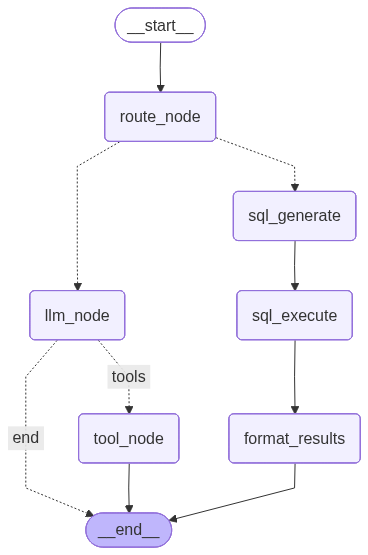

In [24]:
graph=StateGraph(state)
graph.add_node("llm_node",llm_node)
graph.add_node("tool_node",tool_node)
graph.add_node("sql_generate", sql_generate)
graph.add_node("route_node",routerNode)
graph.add_node("sql_execute", sql_execute)
graph.add_edge("sql_execute","format_results")
graph.add_node("format_results", format_results)
graph.add_edge("sql_generate", "sql_execute")
graph.add_edge(START,"route_node")
graph.add_edge("format_results", END)
graph.add_conditional_edges("route_node", route_decision,{
    "llm_node":"llm_node",
    "sql_generate":"sql_generate"
})
graph.add_conditional_edges("llm_node",router,{
    "tools":"tool_node",
    "end":END
})
app=graph.compile()
app

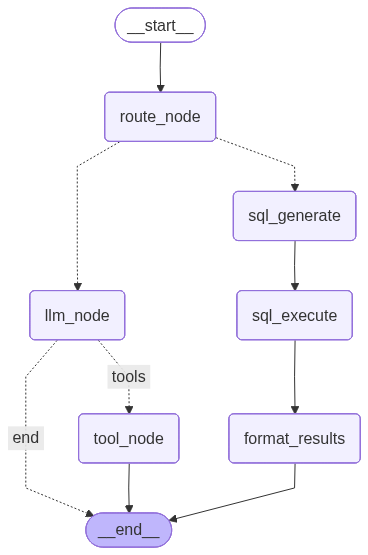

In [25]:
config={"configurable":{"thread_id":"1"}}
memory=InMemorySaver()
app=graph.compile(checkpointer=memory)
app

In [74]:
# res=await app.ainvoke({"messages":HumanMessage(content="What is the current price of silver ETF?")},config=config)
# for msg in res['messages']:
#     print(msg.pretty_print())

In [26]:
res=await app.ainvoke({"messages":HumanMessage(content="Give me the properties located in Gujarat")},config=config)
for msg in res['messages']:
    print(msg.pretty_print())

================================ Human Message =================================

Give me the properties located in Gujarat
None
================================== Ai Message ==================================

We found 10 properties located in Gujarat for you. Some of the properties include the SunsetVilla, an independent house in Ahmedabad with an area of 1950 sq ft, the Shri Hari Bunglows, an independent house in Anand with an area of 2000 sq ft, and the Krupa Bunglows, an independent house in Gandhinagar with an area of 1350 sq ft. You can also find properties in other cities like Vadodara, Surat, and Rajkot. Take a look at these options to find your perfect home.
None


In [19]:
res

{'messages': [HumanMessage(content='Give me the properties located in banglore', additional_kwargs={}, response_metadata={}, id='ed86ff13-48eb-4b07-91ff-9c38c889fd64'),
  HumanMessage(content='Give me the properties located in bengalore', additional_kwargs={}, response_metadata={}, id='b5e537eb-2383-433b-b049-48279b4aec4c'),
  HumanMessage(content='Give me the properties located in bangalore', additional_kwargs={}, response_metadata={}, id='a0b6d3a6-b117-4de3-b25e-db13cc8a0a94'),
  HumanMessage(content='Give me the properties located in Gujarat', additional_kwargs={}, response_metadata={}, id='71c5a9b8-360c-4bca-af8e-42299ce82135')],
 'route': 'sql',
 'sql_query': "SELECT apn, title, city, state, type, area FROM project.property WHERE status = 'Available' AND state ILIKE '%gujarat%' LIMIT 10",
 'sql_results': "{'apn': 5000000010, 'title': 'SunsetVilla', 'city': 'Ahmedabad', 'state': 'Gujarat', 'type': 'Independent House', 'area': Decimal('1950.00')}\n{'apn': 5000000016, 'title': 'Shri 

In [ ]:
def get_db_connection():
    return psycopg2.connect(os.getenv("DATABASE_URL"))


SCHEMA_TEXT_CACHE = None

def fetch_schema_from_db():
    conn = get_db_connection()
    cur = conn.cursor()

    # Columns
    cur.execute("""
        SELECT table_name, column_name, data_type, is_nullable 
        FROM information_schema.columns 
        WHERE table_schema = 'project'
        ORDER BY table_name, ordinal_position
    """)
    columns_rows = cur.fetchall()

    # Primary keys
    cur.execute("""
        SELECT tc.table_name, kcu.column_name
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage kcu
          ON tc.constraint_name = kcu.constraint_name
          AND tc.table_schema = kcu.table_schema
        WHERE tc.constraint_type = 'PRIMARY KEY'
          AND tc.table_schema = 'project'
    """)
    pk_rows = cur.fetchall()

    # Foreign keys
    cur.execute("""
        SELECT 
          tc.table_name AS source_table,
          kcu.column_name AS source_column,
          ccu.table_name AS target_table,
          ccu.column_name AS target_column
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage kcu
          ON tc.constraint_name = kcu.constraint_name
          AND tc.table_schema = kcu.table_schema
        JOIN information_schema.constraint_column_usage ccu
          ON tc.constraint_name = ccu.constraint_name
          AND tc.table_schema = ccu.table_schema
        WHERE tc.constraint_type = 'FOREIGN KEY'
          AND tc.table_schema = 'project'
    """)
    fk_rows = cur.fetchall()

    cur.close()
    conn.close()

    return columns_rows, pk_rows, fk_rows

def convert_schema_to_text(columns_rows, pk_rows, fk_rows):
    tables = {}

    # Step 1: Initialize each table with its columns
    for row in columns_rows:
        table_name, column_name, data_type, is_nullable = row

        if tables.get(table_name) is None:
            tables[table_name] = {
                "columns": [],
                "primary_key": [],
                "foreign_keys": [],
            }

        tables[table_name]["columns"].append({
            "name": column_name,
            "type": data_type,
            "nullable": is_nullable == "YES",
        })

    # Step 2: Attach primary keys
    for row in pk_rows:
        table_name, column_name = row
        if tables.get(table_name) is not None:
            tables[table_name]["primary_key"].append(column_name)

    # Step 3: Attach foreign keys
    for row in fk_rows:
        source_table, source_column, target_table, target_column = row
        if tables.get(source_table) is not None:
            tables[source_table]["foreign_keys"].append({
                "column": source_column,
                "references_table": target_table,
                "references_column": target_column,
            })

    # Step 4: Build the final compact text representation
    lines = []
    for table_name, info in tables.items():
        lines.append(f"Table: {table_name}")

        # Build a quick lookup: column_name -> foreign key info (if any)
        fk_lookup = {fk["column"]: fk for fk in info["foreign_keys"]}

        for col in info["columns"]:
            col_name = col["name"]
            col_type = col["type"]

            tags = []
            if col_name in info["primary_key"]:
                tags.append("PK")
            if col_name in fk_lookup:
                fk = fk_lookup[col_name]
                tags.append(f"FK -> {fk['references_table']}.{fk['references_column']}")

            tag_str = f" ({', '.join(tags)})" if tags else ""
            lines.append(f"  {col_name}: {col_type}{tag_str}")

        lines.append("")  # blank line between tables

    return "\n".join(lines)



In [4]:
columns_rows, pk_rows, fk_rows=fetch_schema_from_db()
print(columns_rows, pk_rows, fk_rows)

[('agent', 'licence_no', 'bigint', 'NO'), ('agent', 'user_id', 'uuid', 'YES'), ('amenities', 'amenity_name', 'text', 'NO'), ('appointment', 'user_id', 'uuid', 'NO'), ('appointment', 'property_id', 'bigint', 'NO'), ('appointment', 'issue_date', 'date', 'NO'), ('appointment', 'issue_time', 'time without time zone', 'NO'), ('appointment', 'visit_date', 'date', 'NO'), ('appointment', 'visit_time', 'time without time zone', 'NO'), ('appointment', 'status', 'USER-DEFINED', 'NO'), ('cash_transaction', 'stamp_paper_no', 'text', 'NO'), ('cash_transaction', 'pay_date', 'date', 'NO'), ('cash_transaction', 'pay_time', 'time without time zone', 'NO'), ('cash_transaction', 'received_by', 'text', 'NO'), ('cheque_transaction', 'cheque_no', 'integer', 'NO'), ('cheque_transaction', 'issue_date', 'date', 'NO'), ('cheque_transaction', 'status', 'USER-DEFINED', 'NO'), ('cheque_transaction', 'bank_name', 'text', 'NO'), ('cheque_transaction', 'stamp_paper_no', 'text', 'NO'), ('cheque_transaction', 'pay_date'

In [5]:
res=convert_schema_to_text(columns_rows, pk_rows, fk_rows)
res

'Table: agent\n  licence_no: bigint (PK)\n  user_id: uuid (FK -> users.user_id)\n\nTable: amenities\n  amenity_name: text (PK)\n\nTable: appointment\n  user_id: uuid (PK, FK -> users.user_id)\n  property_id: bigint (PK, FK -> property.apn)\n  issue_date: date (PK)\n  issue_time: time without time zone (PK)\n  visit_date: date\n  visit_time: time without time zone\n  status: USER-DEFINED\n\nTable: cash_transaction\n  stamp_paper_no: text (PK, FK -> sell_transaction.stamp_paper_no)\n  pay_date: date (PK, FK -> sell_transaction.stamp_paper_no)\n  pay_time: time without time zone (PK, FK -> sell_transaction.stamp_paper_no)\n  received_by: text\n\nTable: cheque_transaction\n  cheque_no: integer (PK)\n  issue_date: date\n  status: USER-DEFINED\n  bank_name: text\n  stamp_paper_no: text (FK -> sell_transaction.stamp_paper_no)\n  pay_date: date (FK -> sell_transaction.stamp_paper_no)\n  pay_time: time without time zone (FK -> sell_transaction.stamp_paper_no)\n\nTable: commission\n  agent_lc_no